In [1]:
import os
import sys
from importlib.metadata import metadata
from pathlib import Path
from skimage import filters

# Automatically locate and add the 'src' folder to sys.path
project_root = Path(os.path.abspath(''))
src_path = project_root / "src"
if src_path not in sys.path:
    sys.path.insert(0, str(src_path))

import numpy as np
import cupy as cp
from imaging import imsave, imread, imshow, using

OG

In [6]:
img, meta = imread(
    f'/data_local/LabVF/PESA-Brain/DATA/Batch1_FP/QVTPlus/PESA10758400/_FixedVel/BMRI607930_4DQflowNeuro_AP_2003_m_MIP.nii',
    axes='XYZ'
)

print(img.shape)
print(meta['affine'])
# imshow(img[..., 0], axis=2)

(256, 256, 101)
[[ 7.76844323e-01 -3.41637135e-02 -1.57620907e-02 -9.74834976e+01]
 [ 3.31390500e-02  7.75496781e-01 -5.03449440e-02 -1.04164383e+02]
 [ 1.74291730e-02  4.82347012e-02  7.98258841e-01 -1.00079212e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [7]:
frangi_img = filters.frangi(
    img.get() if hasattr(img, 'get') else img,
    sigmas=range(1, 10, 2),
    scale_range=None,
    scale_step=None,
    black_ridges=False,
    alpha=0.5,
    beta=0.5,
    gamma=None,
    mode='reflect',
    cval=0,
)

imsave(
    # '/data_local/LabVF/PESA-Brain/DATA/Batch1_FP/FrangiTest/QVT_CD_frangi.nii.gz', 
    '/data_local/LabVF/PESA-Brain/DATA/Batch1_FP/FrangiTest/BMRI607930_4DQflowNeuro_AP_2003_m_MIP_frangi.nii', 
    frangi_img,
    metadata=meta
)

TypeError: Invalid shape (256, 256, 101) for image data

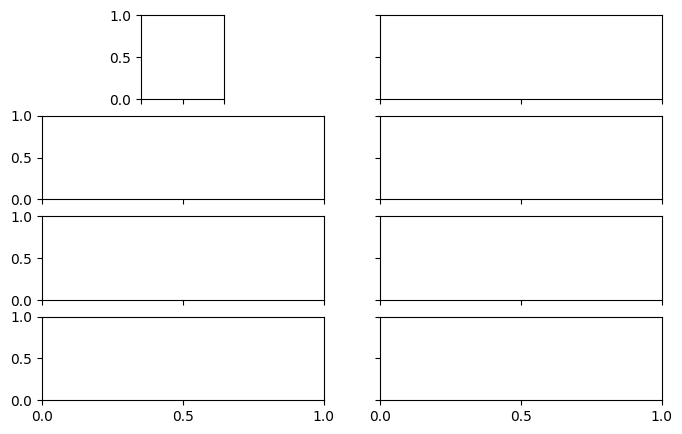

: 

In [ ]:
frangi_th = filters.threshold_otsu(frangi_img)
frangi_mask = frangi_img > frangi_th

imsave(
    '/data_local/LabVF/PESA-Brain/DATA/Batch1_FP/FrangiTest/BMRI607930_4DQflowNeuro_AP_2003_m_MIP_frangi_mask.nii', 
    frangi_mask.astype(np.uint8),
    metadata=meta
)


In [9]:
meta

{'sizeof_hdr': array(348, dtype=int32),
 'data_type': array(b'', dtype='|S10'),
 'db_name': array(b'?TR:23.000 TE:3', dtype='|S18'),
 'extents': array(0, dtype=int32),
 'session_error': array(0, dtype=int16),
 'regular': array(b'', dtype='|S1'),
 'dim_info': array(0, dtype=uint8),
 'dim': array([  3, 800, 800, 180,   1,   1,   1,   1], dtype=int16),
 'intent_p1': array(0., dtype=float32),
 'intent_p2': array(0., dtype=float32),
 'intent_p3': array(0., dtype=float32),
 'intent_code': array(0, dtype=int16),
 'datatype': array(64, dtype=int16),
 'bitpix': array(64, dtype=int16),
 'slice_start': array(0, dtype=int16),
 'pixdim': array([1.       , 0.25     , 0.25     , 0.5000005, 0.023    , 1.       ,
        1.       , 1.       ], dtype=float32),
 'vox_offset': array(0., dtype=float32),
 'scl_slope': array(nan, dtype=float32),
 'scl_inter': array(nan, dtype=float32),
 'slice_end': array(0, dtype=int16),
 'slice_code': array(0, dtype=uint8),
 'xyzt_units': array(2, dtype=uint8),
 'cal_max':

In [3]:
img, meta = imread(
    f'/data_local/BioIT/PESA-Fat/PESA_Fat_Visit4_IGL/ALL_MR_FOV_Fat/IA869121_MR_F/tissue_types_mr.nii',
    axes='XYZ'
)

print(img.shape)
print(meta['affine'])
# imshow(img[..., 0], axis=2)

(221, 256, 256)
[[   1.80000305    0.            0.         -197.4447937 ]
 [   0.            1.7578125     0.         -218.42202759]
 [   0.            0.            1.7578125  -427.41070557]
 [   0.            0.            0.            1.        ]]


IMS

(256, 256, 101, 15)
[[ 7.76844323e-01 -3.41637731e-02 -1.57620907e-02 -9.74834976e+01]
 [ 3.31390686e-02  7.75496781e-01 -5.03449440e-02 -1.04164383e+02]
 [ 1.74291451e-02  4.82347310e-02  7.98258841e-01 -1.00079212e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


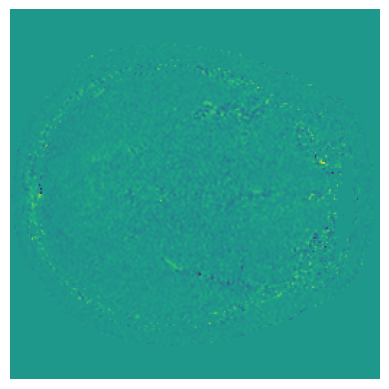

In [8]:
img, meta = imread(
    f'/data_local/LabVF/PESA-Brain/DATA/Batch1/Nifti_Reorganized/PESA10758400/4DFlow/AP/BMRI607930_4DQflowNeuro_AP_2003_ph.nii.gz',
    axes='XYZC'
)

print(img.shape)
print(meta['affine'])
imshow(img[..., 0], axis=2)

(800, 800, 180)
[[ 2.49710113e-01 -1.09816594e-02 -9.85119492e-03 -9.80701675e+01]
 [ 1.06522767e-02  2.49276966e-01 -3.14655416e-02 -1.04606125e+02]
 [ 5.60245337e-03  1.55046517e-02  4.98912156e-01 -1.48077145e+01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


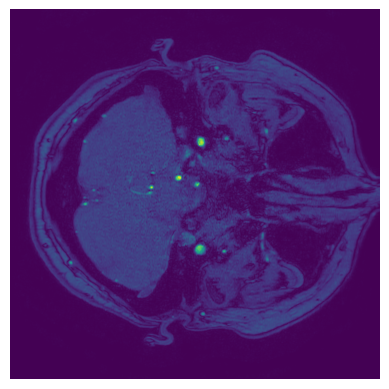

In [7]:
img, meta = imread(
    f'/data_local/LabVF/PESA-Brain/DATA/Batch1/Nifti_Reorganized/PESA10758400/TOF/BMRI607930_cs3DI_MC_1601.nii.gz',
    axes='XYZ'
)

print(img.shape)
print(meta['affine'])
imshow(img[..., 0], axis=2)

In [8]:
X, Y, Z, T = img.shape
mid = Z // 2

vol_top = img[:, :, :mid, :]
vol_bottom = img[:, :, mid:, :]

In [9]:
print(vol_top.shape)
print(vol_bottom.shape)

(256, 256, 101, 15)
(256, 256, 101, 15)


In [11]:
imsave('/data_local/BioIT_Data/test/BMRI7358789_4DQflowNeuro_RL_1805_m.nii.gz', vol_top, metadata=meta)
imsave('/data_local/BioIT_Data/test/BMRI7358789_4DQflowNeuro_RL_1805_ph.nii.gz', vol_bottom, metadata=meta)

Could not set zooms for NIfTI file: Image dimension 4 not supported for NIfTI file.
Could not set zooms for NIfTI file: Image dimension 4 not supported for NIfTI file.
